# Bloque 1 — Fundamentos: Transformers, LLMs y Representación Vectorial

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01-fundamentos.ipynb)

> **Carga:** HT: 6h \| HPD: 4h
>
> **Competencias asociadas:**
> [CE-1](../index.qmd#competencias-específicas)
>
> **Dependencias:** `torch`, `transformers`, `sentence-transformers`,
> `chromadb`, `faiss-cpu`, `matplotlib`, `scikit-learn`, `numpy`

> **Ejecución en Colab**
>
> Todas las celdas de código están diseñadas para ejecutarse en **Google
> Colab** con GPU T4 gratuita (12 GB RAM).
>
> 1.  Haz clic en el badge “Open in Colab” de arriba
> 2.  Si es la primera vez, autoriza Colab en GitHub: **Settings →
>     GitHub → Connect to GitHub**
> 3.  En Colab: `Runtime → Run all`
>
> Si el badge no funciona, abre
> [colab.research.google.com](https://colab.research.google.com), ve a
> **File → Open Notebook → GitHub**, busca `Adamychen/m10_quarto` y
> selecciona el notebook correspondiente.

## Objetivos del bloque

Comprender la arquitectura que subyace a los LLMs modernos y dominar la
representación vectorial de texto y datos tabulares, así como las bases
de datos vectoriales para búsqueda semántica y recuperación de
información.

## Mapa conceptual del bloque

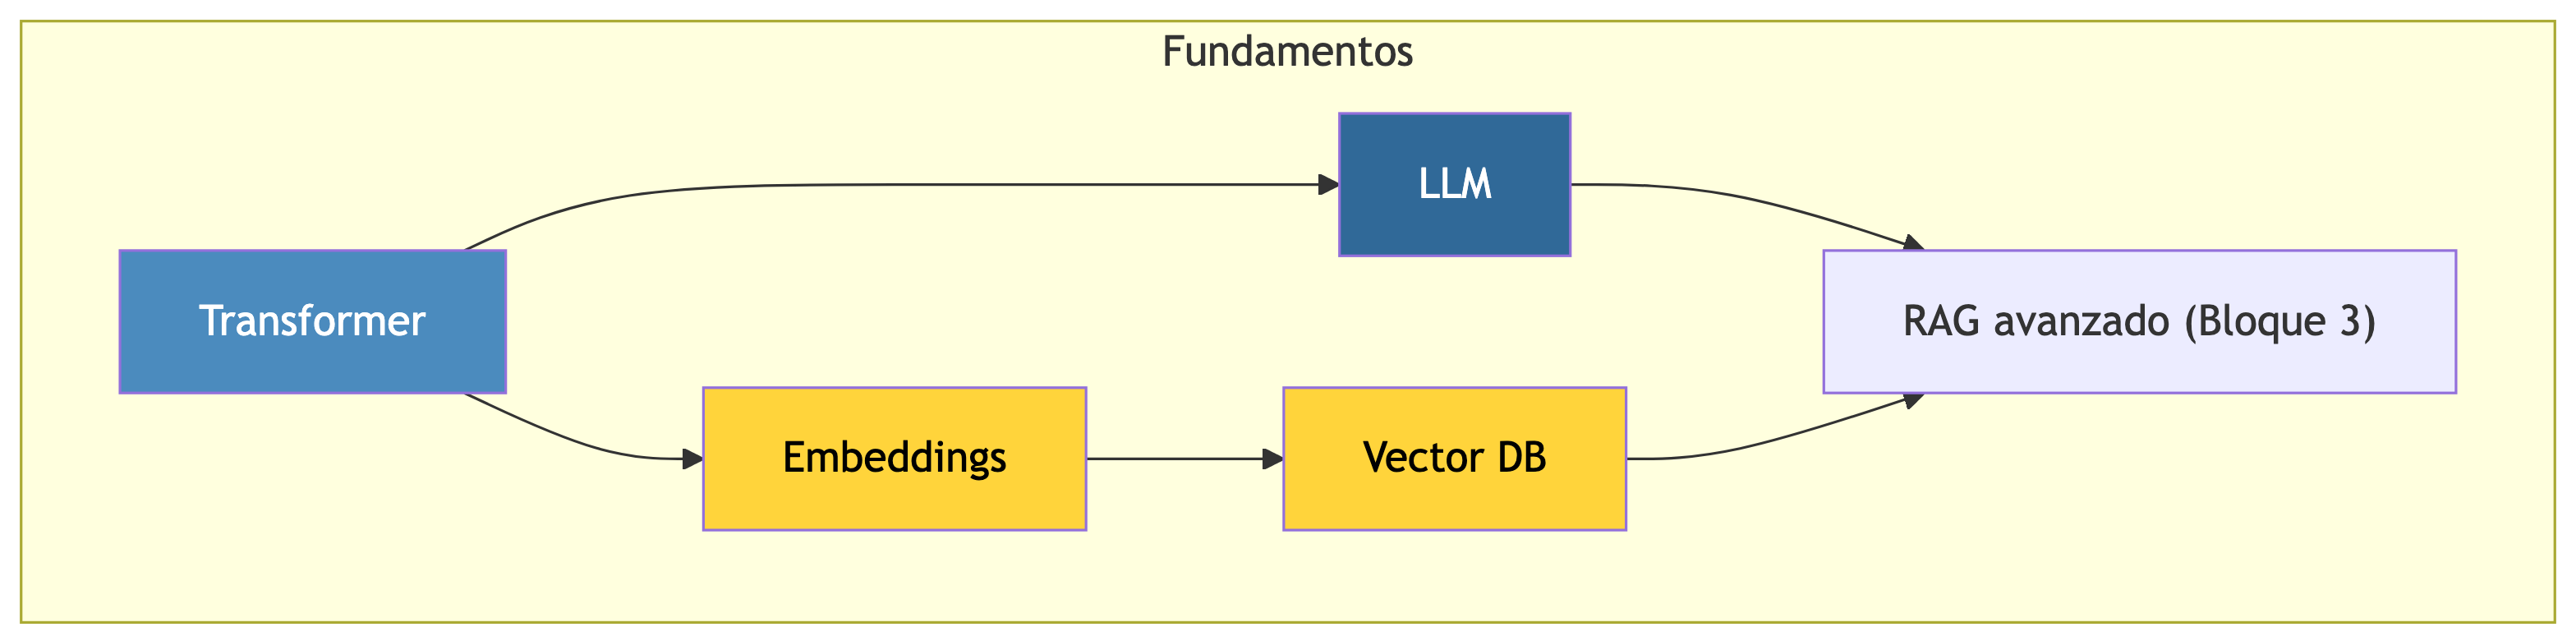

Los cuatro pilares de este bloque (Transformer → LLM → Embeddings →
Vector DB) actúan como soporte sobre el que se construye todo el módulo.
El orden sigue una progresión natural basada en dependencias: comenzamos
los fundamentos de la arquitectura Transformer, pasamos a exponer cómo
esta arquitectura escala para construir los LLMs (en su forma más
general), continuaremos con la representación de la información haciendo
uso de vectores numéricos por medio de los embeddings y, finalmente,
explicaremos algunos métodos para almacenar y recuperar esos vectores de
representación de forma eficiente.

## Contenido del bloque

La siguiente tabla muestra el itinerario que sigue este bloque en su
exposición de objetivos, así como los ficheros interactivos asociados y
el tiempo estimado necesario para la exposición de los mismos:

| Tema | Archivo | Duración estimada |
|------------------------|------------------------|------------------------|
| **Transformers** — Atención, codificación posicional, variantes | [01a-transformer.qmd](01a-transformer.qmd) | 2h |
| **LLMs e inferencia** — Preentrenamiento, tokenización, parámetros, HF Hub, API Llamus | [01b-llms.qmd](01b-llms.qmd) | 2h |
| **Embeddings** — word2vec, SBERT, modelos, comparativa | [01c-embeddings.qmd](01c-embeddings.qmd) | 1h |
| **Bases de datos vectoriales** — Chroma, FAISS, HNSW, búsqueda semántica | [01d-vectordb.qmd](01d-vectordb.qmd) | 1h |
| **HPD 1 — Pipeline de embeddings** | [hpd1-embeddings.qmd](../evaluables/hpd1-embeddings.qmd) | 4h |

> **Note**
>
> **Teoría obligatoria.** Los temas listados arriba son obligatorios.
> Puedes profundizar en cada uno según tu interés.

In [1]:
!pip install -q chromadb faiss-cpu sentence-transformers


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.rcParams["figure.dpi"] = 100
import math
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
print("Librerías cargadas correctamente.")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")


Librerías cargadas correctamente.
NumPy: 1.26.4
PyTorch: 2.12.0

------------------------------------------------------------------------

## Referencias del bloque

- Devlin, J., Chang, M., Lee, K. & Toutanova, K. (2018). **BERT:
  Pre-training of Deep Bidirectional Transformers for Language
  Understanding**. arXiv:1810.04805
- Vaswani, A. et al. (2017). **Attention is All You Need**. NeurIPS.
  [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
- Kaplan, J. et al. (2020). **Scaling Laws for Neural Language Models**.
  arXiv:2001.08361
- Hoffmann, J. et al. (2022). **Training Compute-Optimal Large Language
  Models** (Chinchilla). arXiv:2203.15556
- Su, J. et al. (2021). **RoFormer: Enhanced Transformer with Rotary
  Position Embedding** (RoPE). arXiv:2104.09864
- Dao, T. et al. (2022). **FlashAttention: Fast and Memory-Efficient
  Exact Attention with IO-Awareness**. arXiv:2205.14135
- Reimers, N. & Gurevych, I. (2019). **Sentence-BERT: Sentence
  Embeddings using Siamese BERT-Networks**.
  [arXiv:1908.10084](https://arxiv.org/abs/1908.10084)
- Wang, L. et al. (2022). **Text Embeddings by Weakly-Supervised
  Contrastive Pre-training** (E5). arXiv:2212.03533
- Radford, A. et al. (2021). **Learning Transferable Visual Models From
  Natural Language Supervision** (CLIP). arXiv:2103.00020
- Malkov, Y. & Yashunin, D. (2018). **Efficient and robust approximate
  nearest neighbor search using Hierarchical Navigable Small World
  graphs** (HNSW). IEEE TPAMI.
  [arXiv:1603.09320](https://arxiv.org/abs/1603.09320)
- Johnson, J., Douze, M. & Jégou, H. (2019). **Billion-scale similarity
  search with GPUs** (FAISS). IEEE TBD.
  [arXiv:1702.08734](https://arxiv.org/abs/1702.08734)

------------------------------------------------------------------------

## Resumen del bloque

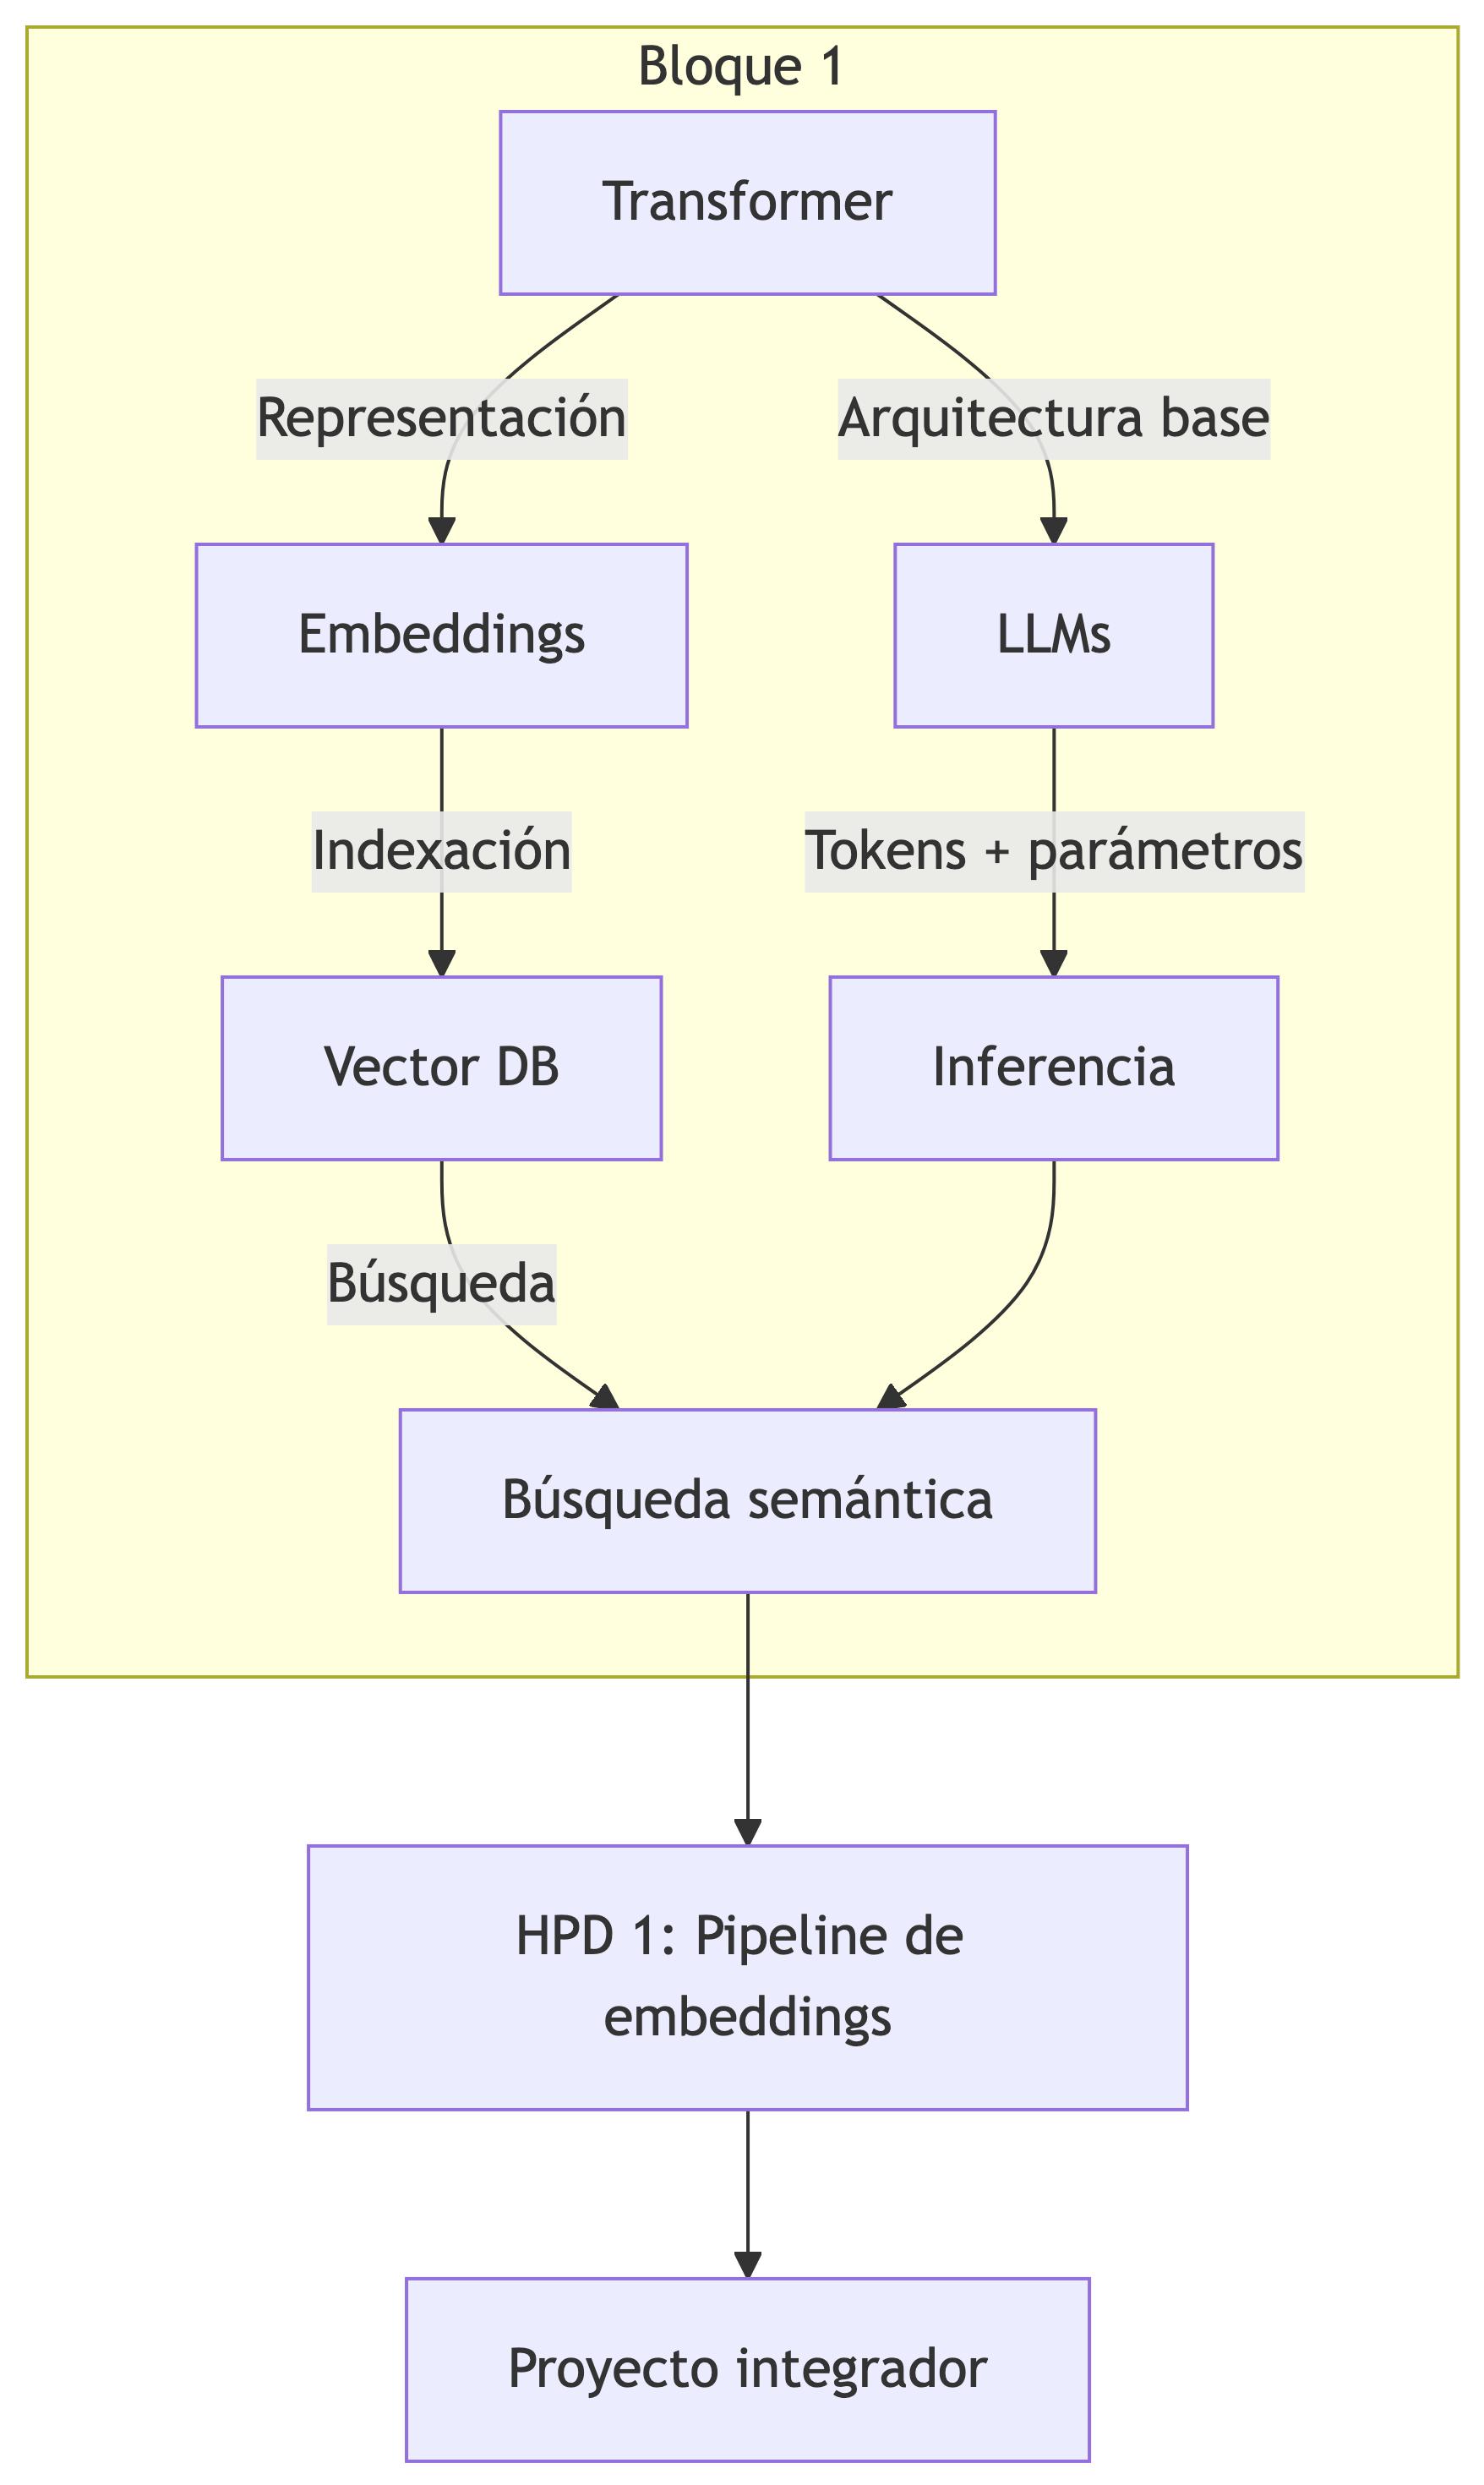

Este primer bloque sienta las bases para el resto de bloques que
componen el curso. Concretamente:

- **Bloque 2:** uso de LLMs para construir agentes y prompts
  estructurados
- **Bloque 3:** uso de embeddings + vector DB para construir sistemas
  RAG (recuperación de información)
- **Bloque 4:** evaluación y despliegue de sistemas en producción

Tras haber asimilado los conceptos de las secciones anteriores, puedes
pasar al [taller práctico: HPD 1 — Pipeline de embeddings y búsqueda
semántica](../evaluables/hpd1-embeddings.qmd).

> **Antes de continuar**
>
> 1.  Asegúrate de haber ejecutado `source .venv/bin/activate` (o
>     `setup.bat` en Windows)
> 2.  Confirma que ejecutaste todas las celdas de código de los
>     sub-temas sin errores
> 3.  Lee Vaswani et al. (2017) secciones 3-5 (lectura obligatoria)